# Hubbard model

We consider the one-dimensional Fermi-Hubbard model
$$
H = -t\sum_{j=1}^{L-1} \sum_{\sigma\in\{\uparrow,\downarrow\}} c_{j,\sigma}^\dagger c_{j+1,\sigma}+U\sum_{j=1}^L (n_{j,\uparrow}-\frac{1}{2})(n_{j,\downarrow}-\frac{1}{2})\,.
$$

### Parameter setting:

- **Task:** Thermal state preparation
- **Figure:** Spectral gap
- **System size:** $L=2$ sites
- **Inverse temperature:**  $\beta=1$
- **Gaussian filter width:** $\sigma=2$
- **Coupling strengths:** $\Gamma \in \{1, 0.5, 0.25, 0.1, 0.05, 0.01\}$
- **Bath frequency sampling:** $\omega$ is sampled from the Gaussian distribution associated with the KMS Lindbladian.
- **System operator sampling:** fermionic ladder operators

In [1]:
import quimb as qu
import numpy as np

import scipy.sparse as sp
from scipy.linalg import expm
from scipy.sparse import coo_matrix
from numpy.polynomial.hermite import hermgauss

import matplotlib as mpl # noqa
import matplotlib.pyplot as plt # noqa
from tqdm import tqdm

from hamiltonians import hubbard_spinful_fermi,jw_fermion_ops_flat
from channels import construct_unified_channel,analyze_fixed_point

import warnings
import os
def short_warning(message, category, filename, lineno, line=None):
    return f"{os.path.basename(filename)}:{lineno}: {category.__name__}: {message}\n"
warnings.formatwarning = short_warning


op_kws = {'sparse': True, 'stype': 'coo'}
ikron_kws = {'sparse': True, 'stype': 'coo',
             'coo_build': True, 'ownership': None}

N=2 #number of sites in the physical model
dsys = 2 ** (2*N) # system dimension
beta = 1 #inverse temperature
sigma = 2 * beta #width of the Gaussian pulse
dTime = 0.1 #time step size in one iteration
# BB = 5 #maximum bath frequency
alpha_list = np.array([1, 0.5, 0.25, 0.1, 0.05, 0.01]) / (sigma**0.5) #different choice of alpha


# spinless fermi hubbard model
Hamsys = hubbard_spinful_fermi(N, t = 1.0, U=-4.0, op_kws=op_kws, ikron_kws=ikron_kws)
Hamsys = Hamsys.toarray()
rhogibbs = expm(-beta*Hamsys)
rhogibbs = rhogibbs/rhogibbs.trace()
As_op_array = jw_fermion_ops_flat(N) #sample from fermionic operators

#simulation loop
sigma_list=[sigma, 2*sigma, 4*sigma]
fidelity_list = np.zeros((len(alpha_list), len(sigma_list)))
spectral_gap_list = np.zeros((len(alpha_list), len(sigma_list)))
for idx, alpha in enumerate(alpha_list):
    for sidx, sigma_t in enumerate(sigma_list):
        print(f"\n=== Running channel for Γ/√σ = {alpha:.2e}, σ = {sigma_t:.2f} ===")
        channel_unified = construct_unified_channel(Hamsys_base=Hamsys, As_ops=As_op_array, alpha=alpha, beta=beta, sigma=sigma_t, dTime=dTime)
        # Analyze fixed points
        rho_fixed_unified, fidelity_list[idx,sidx], spectral_gap_list[idx,sidx] = analyze_fixed_point(
            channel_unified, "Unified Protocol", rhogibbs)


_matfuncs.py:326: RuntimeWarning: divide by zero encountered in matmul
_matfuncs.py:326: RuntimeWarning: overflow encountered in matmul
_matfuncs.py:326: RuntimeWarning: invalid value encountered in matmul
_matfuncs.py:358: RuntimeWarning: divide by zero encountered in matmul
_matfuncs.py:358: RuntimeWarning: overflow encountered in matmul
_matfuncs.py:358: RuntimeWarning: invalid value encountered in matmul



=== Running channel for Γ/√σ = 7.07e-01, σ = 2.00 ===
Constructing unified channel ( β = 1)...


Bath frequencies:   0%|          | 0/201 [00:00<?, ?it/s]channels.py:27: RuntimeWarning: divide by zero encountered in matmul
channels.py:27: RuntimeWarning: overflow encountered in matmul
channels.py:27: RuntimeWarning: invalid value encountered in matmul
channels.py:126: RuntimeWarning: divide by zero encountered in matmul
channels.py:126: RuntimeWarning: overflow encountered in matmul
channels.py:126: RuntimeWarning: invalid value encountered in matmul
channels.py:127: RuntimeWarning: divide by zero encountered in matmul
channels.py:127: RuntimeWarning: overflow encountered in matmul
channels.py:127: RuntimeWarning: invalid value encountered in matmul
channels.py:136: RuntimeWarning: divide by zero encountered in matmul
channels.py:136: RuntimeWarning: overflow encountered in matmul
channels.py:136: RuntimeWarning: invalid value encountered in matmul
Bath frequencies: 100%|██████████| 201/201 [00:34<00:00,  5.81it/s]
base_linalg.py:596: RuntimeWarning: divide by zero encountered in 


=== Unified Protocol Fixed Point Analysis ===

=== Running channel for Γ/√σ = 7.07e-01, σ = 4.00 ===
Constructing unified channel ( β = 1)...


Bath frequencies: 100%|██████████| 201/201 [00:45<00:00,  4.42it/s]


...


=== Unified Protocol Fixed Point Analysis ===

=== Running channel for Γ/√σ = 7.07e-03, σ = 4.00 ===
Constructing unified channel ( β = 1)...


Bath frequencies: 100%|██████████| 201/201 [00:42<00:00,  4.68it/s]



=== Unified Protocol Fixed Point Analysis ===

=== Running channel for Γ/√σ = 7.07e-03, σ = 8.00 ===
Constructing unified channel ( β = 1)...


Bath frequencies: 100%|██████████| 201/201 [01:02<00:00,  3.22it/s]


=== Unified Protocol Fixed Point Analysis ===


# Plot figures

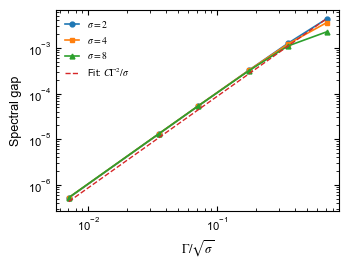

In [2]:
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

def model(alpha, C):
    return C*alpha**2

# Fit the data
popt, pcov = curve_fit(model, alpha_list, spectral_gap_list[:,0])
C_fit = popt[0]
# Generate smooth curve for plotting
alpha_fit = np.linspace(min(alpha_list), max(alpha_list), 200)
gap_fit = model(alpha_fit, C_fit)

markers = ['o', 's', '^', 'D', 'v', 'x', '*', 'p', 'h']

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "mathtext.fontset": "stix",
    "axes.linewidth": 0.8,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True,
    "pdf.fonttype": 42, "ps.fonttype": 42,
})

fig, ax = plt.subplots(figsize=(3.35, 2.55))  

for idx, sigma_t in enumerate(sigma_list):
    plt.plot(alpha_list, spectral_gap_list[:, idx],linewidth=1.2,
        label=rf'$\sigma={sigma_t}$', marker=markers[idx], markersize=3.5)

plt.plot(alpha_fit, gap_fit, '--', linewidth=1.0, label=rf'Fit: $C\Gamma^2/\sigma$' )

plt.xlabel(r'$\Gamma/\sqrt{\sigma}$', fontsize=9)
plt.ylabel(r'Spectral gap', fontsize=9)

plt.xscale('log', base=10)
plt.yscale('log', base=10)

plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

plt.legend(fontsize=7, loc='upper left', frameon=False, handlelength=1.5)
plt.grid(False)

plt.tight_layout(pad=0.2)

plt.savefig( "figures/Hubbard_2_channel_spectral_gap_Gaussian.pdf", format="pdf", bbox_inches="tight", dpi=300)

plt.show()